# Fairness Audit Lab — Auditing & Mitigating Bias in a Hiring/Income AI

**Trustworthy AI · Week 5 Lecture 2 — Fairness Audit Lab**

*Cell 1 (markdown) · Introduction*

We play the role of an **AI auditor** reviewing an income-prediction model (a stand-in
for an automated hiring / screening system). The model predicts whether a person earns
**> \$50K** from the **UCI Adult Income** dataset. The protected/sensitive attributes are
**Sex, Race, and Age**.

### Lab workflow (from the lecture)
> **Dataset → Train Model → Measure Fairness → Identify Bias → Apply Mitigation → Re-evaluate**

### What we will do
1. **Step 1 — Train a baseline model** and record Accuracy, Precision, Recall.
2. **Step 2 — Measure fairness** across groups using **Demographic Parity** and **Equal Opportunity**.
3. **Step 3 — Identify sources of bias** (historical, sampling, measurement, model).
4. **Step 4 — Apply a mitigation technique** (Reweighing).
5. **Step 5 — Re-train and re-evaluate**, comparing accuracy and fairness before vs after.

### Fairness metrics used (definitions from Lecture 1)
| Metric | Question | Formula |
|---|---|---|
| **Demographic Parity** | Are *outcomes* equal across groups? | `P(ŷ=1 | group A) = P(ŷ=1 | group B)` |
| **Equal Opportunity** | Are *qualified* people treated equally? | `TPR_A = TPR_B`, where `TPR = TP / (TP + FN)` |

A perfectly fair model (under a metric) has a **difference of 0** between groups.

> **Note:** this notebook is self-contained. It downloads the dataset itself via
> `sklearn.datasets.fetch_openml` and runs top-to-bottom with no external files.

## Setup

*Cell 2 (markdown) · Imports & configuration*

We use only the lab's suggested core libraries: **pandas, numpy, scikit-learn, matplotlib**.
Fairness metrics are implemented from scratch (no `fairlearn`/`aif360` dependency) so the
maths is fully visible.

In [1]:
# Cell 3 (code) -- Imports & global configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, confusion_matrix,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Consistent colours for "before vs after" and group plots
C_BASE, C_MIT = "#4C72B0", "#55A868"      # baseline (blue) / mitigated (green)
C_A, C_B = "#4C72B0", "#DD8452"           # group A / group B

print("Libraries loaded. scikit-learn ready for the fairness audit.")

Libraries loaded. scikit-learn ready for the fairness audit.


## Dataset — UCI Adult Income

*Cell 4 (markdown) · Load the data*

The **Adult** dataset (~48,800 rows) is downloaded directly from OpenML. The prediction
target is `income = 1` when a person earns **> \$50K**. We keep `sex`, `race`, and a derived
`age_group` aside as **sensitive attributes** for the fairness audit.

In [2]:
# Cell 5 (code) -- Download and prepare the raw dataframe
adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame.copy()

# Binary target: 1 = earns >50K (the "positive"/favourable outcome)
df["income"] = (df["class"].astype(str) == ">50K").astype(int)
df = df.drop(columns=["class"])

# Normalise missing markers ("?") to NaN
df = df.replace("?", np.nan)

# Derived sensitive attribute: age group (<=35 vs >35)
df["age_group"] = np.where(df["age"] <= 35, "<=35", ">35")

print("Shape:", df.shape)
print("\nIncome balance (0 = <=50K, 1 = >50K):")
print(df["income"].value_counts(normalize=True).round(3).to_string())
df.head()

Shape: (48842, 16)

Income balance (0 = <=50K, 1 = >50K):
income
0    0.761
1    0.239


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,age_group
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0,<=35
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0,>35
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1,<=35
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1,>35
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0,<=35


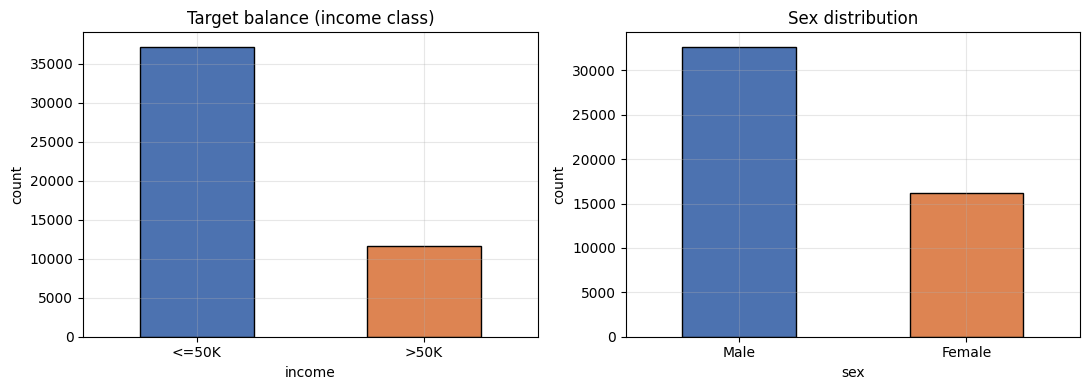

In [3]:
# Cell 6 (viz) -- Class balance + sex distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

(df["income"].map({0: "<=50K", 1: ">50K"}).value_counts()
   .reindex(["<=50K", ">50K"])
   .plot(kind="bar", ax=axes[0], color=[C_A, C_B], edgecolor="black"))
axes[0].set_title("Target balance (income class)")
axes[0].set_ylabel("count"); axes[0].tick_params(axis="x", rotation=0)

(df["sex"].value_counts()
   .plot(kind="bar", ax=axes[1], color=[C_A, C_B], edgecolor="black"))
axes[1].set_title("Sex distribution")
axes[1].set_ylabel("count"); axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout(); plt.show()

## Exploratory check — does the *data itself* look biased?

*Cell 7 (markdown) · Positive-outcome rate by group*

Before any model exists, we look at the **base rate** — the share of each group that
actually earns > \$50K in the historical data. Large gaps here are a signal of
**historical bias**: the data reflects past societal inequality, and any model trained on
it will tend to reproduce that gap.

In [4]:
# Cell 7 (code) -- Base (>50K) rate by each sensitive attribute
rate_sex = df.groupby("sex", observed=True)["income"].mean().sort_values()
rate_race = df.groupby("race", observed=True)["income"].mean().sort_values()
rate_age = df.groupby("age_group", observed=True)["income"].mean().sort_values()

for name, s in [("SEX", rate_sex), ("RACE", rate_race), ("AGE GROUP", rate_age)]:
    print(f"--- >50K base rate by {name} ---")
    print((s * 100).round(1).astype(str).add(" %").to_string(), "\n")

--- >50K base rate by SEX ---
sex
Female    10.9 %
Male      30.4 % 

--- >50K base rate by RACE ---
race
Amer-Indian-Eskimo    11.7 %
Black                 12.1 %
Other                 12.3 %
White                 25.4 %
Asian-Pac-Islander    26.9 % 

--- >50K base rate by AGE GROUP ---
age_group
<=35    11.4 %
>35     34.5 % 



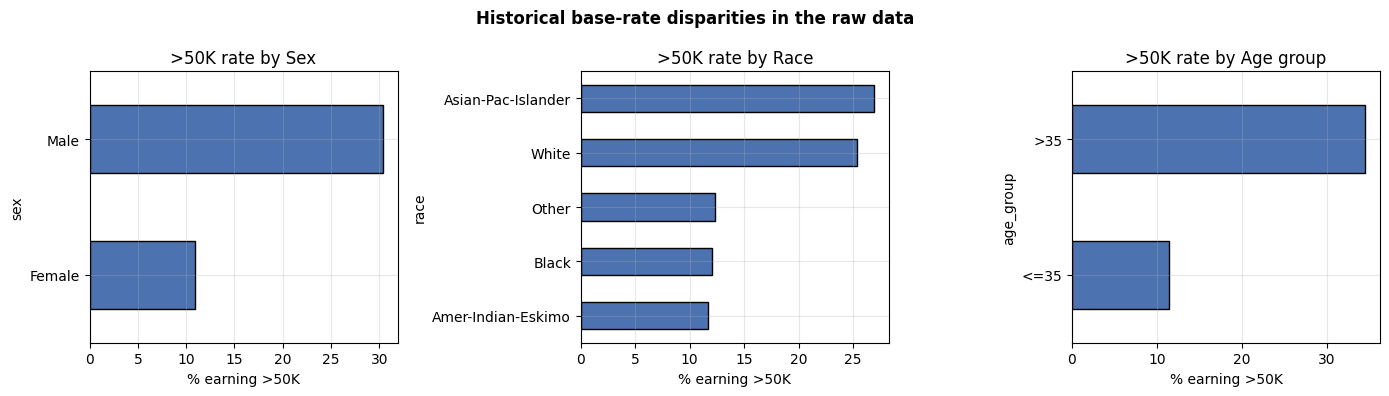

In [5]:
# Cell 8 (viz) -- Base-rate disparities across the three sensitive attributes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, s, title in zip(
    axes, [rate_sex, rate_race, rate_age], ["Sex", "Race", "Age group"]
):
    (s * 100).plot(kind="barh", ax=ax, color=C_BASE, edgecolor="black")
    ax.set_title(f">50K rate by {title}")
    ax.set_xlabel("% earning >50K")
fig.suptitle("Historical base-rate disparities in the raw data", fontweight="bold")
plt.tight_layout(); plt.show()

## Preprocessing & train/test split

*Cell 9 (markdown) · Build features*

**Design choice:** we **drop `sex` and `race` from the model inputs** and audit them
separately. This mirrors a key lecture takeaway — *removing protected attributes is not
enough*: the model can still discriminate through **proxy variables** (e.g.
`relationship`, `marital-status`, `occupation`, `hours-per-week`). Keeping them out of `X`
lets us test exactly that.

- Numeric features → standardised.
- Categorical features → one-hot encoded (`handle_unknown="ignore"`).
- Split: 75% train / 25% test, stratified on the target. The sensitive columns are split
  in lock-step so each test row keeps its group labels for the audit.

In [6]:
# Cell 10 (code) -- Feature matrix, sensitive frame, and stratified split
sensitive_cols = ["sex", "race", "age_group"]

# Columns excluded from the MODEL (protected attrs + redundant/identifier cols)
drop_for_model = ["income", "sex", "race", "age_group", "fnlwgt", "education"]
feature_df = df.drop(columns=drop_for_model).reset_index(drop=True)

cat_cols = feature_df.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = feature_df.select_dtypes(include=["number"]).columns.tolist()

# Make categoricals string + fill missing so the encoder is happy
for c in cat_cols:
    feature_df[c] = feature_df[c].astype(str).replace("nan", "Unknown")

X = feature_df
y = df["income"].reset_index(drop=True)
sens = df[sensitive_cols].reset_index(drop=True)

X_train, X_test, y_train, y_test, sens_train, sens_test = train_test_split(
    X, y, sens, test_size=0.25, stratify=y, random_state=RANDOM_STATE,
)

# Reset indices on the split pieces so positional masks line up later
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
sens_train = sens_train.reset_index(drop=True)
sens_test = sens_test.reset_index(drop=True)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

print(f"Model features: {len(num_cols)} numeric + {len(cat_cols)} categorical")
print(f"  numeric:     {num_cols}")
print(f"  categorical: {cat_cols}")
print(f"\nTrain rows: {len(X_train):,}   Test rows: {len(X_test):,}")
print("Protected attributes held out of X and audited separately:", sensitive_cols)

Model features: 5 numeric + 5 categorical
  numeric:     ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
  categorical: ['workclass', 'marital-status', 'occupation', 'relationship', 'native-country']

Train rows: 36,631   Test rows: 12,211
Protected attributes held out of X and audited separately: ['sex', 'race', 'age_group']


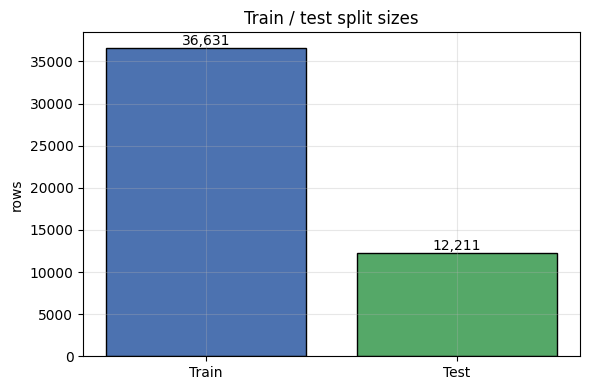

In [7]:
# Cell 11 (viz) -- Train/test split sizes
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Train", "Test"], [len(X_train), len(X_test)],
       color=[C_BASE, C_MIT], edgecolor="black")
for i, v in enumerate([len(X_train), len(X_test)]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
ax.set_title("Train / test split sizes"); ax.set_ylabel("rows")
plt.tight_layout(); plt.show()

## Step 1 — Train a Baseline Model

*Cell 12 (markdown)*

We train a **Logistic Regression** baseline (one of the lecture's suggested choices) inside
a pipeline that handles preprocessing. We then record **Accuracy, Precision, and Recall**
on the held-out test set — the standard performance numbers, *before* we look at fairness.

In [8]:
# Cell 13 (code) -- Fit baseline model and record performance
baseline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)

base_perf = {
    "accuracy":  accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall":    recall_score(y_test, y_pred),
}
print("Baseline performance (test set):")
for k, v in base_perf.items():
    print(f"  {k:10s}: {v:.3f}")

Baseline performance (test set):
  accuracy  : 0.854
  precision : 0.744
  recall    : 0.592


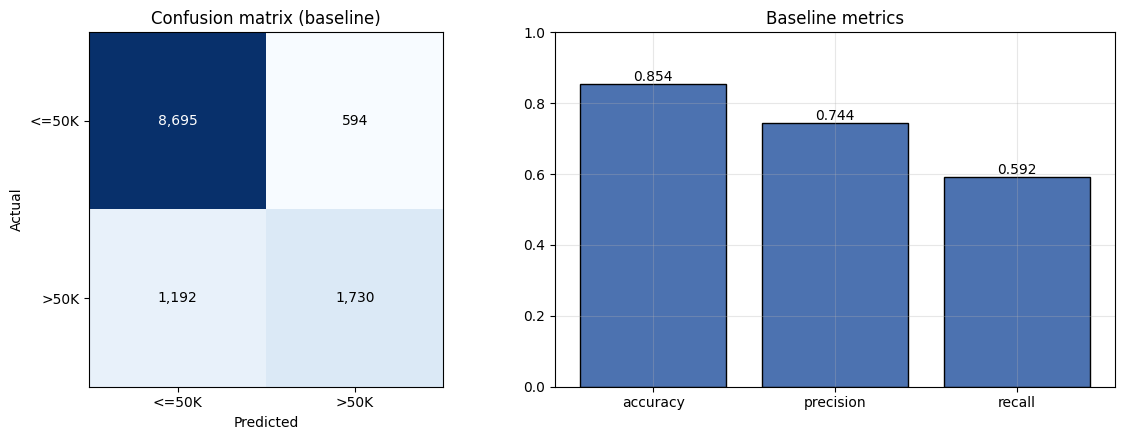

In [9]:
# Cell 14 (viz) -- Confusion matrix + performance metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test, y_pred)
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion matrix (baseline)")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["<=50K", ">50K"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["<=50K", ">50K"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual"); axes[0].grid(False)
for (r, c), val in np.ndenumerate(cm):
    axes[0].text(c, r, f"{val:,}", ha="center", va="center",
                 color="white" if val > cm.max() / 2 else "black")

axes[1].bar(list(base_perf), list(base_perf.values()),
            color=C_BASE, edgecolor="black")
axes[1].set_ylim(0, 1); axes[1].set_title("Baseline metrics")
for i, v in enumerate(base_perf.values()):
    axes[1].text(i, v, f"{v:.3f}", ha="center", va="bottom")

plt.tight_layout(); plt.show()

## Step 2 — Measure Fairness

*Cell 15 (markdown) · Fairness metric helpers*

We implement the two metrics from Lecture 1 directly:

- **Selection rate** for a group = `P(ŷ = 1 | group)` → drives **Demographic Parity**.
- **TPR** for a group = `TP / (TP + FN)` (among people who *actually* earn >50K, how many
  did we correctly predict?) → drives **Equal Opportunity**.

The **disparity** for each metric is `max(group) − min(group)`; **0 = perfectly fair**.

In [10]:
# Cell 16 (code) -- Fairness metric functions + per-group table for SEX
def group_fairness_table(y_true, y_pred, group):
    '''Per-group selection rate, TPR and base rate. Inputs are array-likes.'''
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    group = np.asarray(group)
    rows = []
    for g in pd.unique(group):
        m = group == g
        pos = m & (y_true == 1)               # actually-qualified people in the group
        rows.append({
            "group": g,
            "n": int(m.sum()),
            "selection_rate": y_pred[m].mean(),
            "tpr": y_pred[pos].mean() if pos.sum() else np.nan,
            "base_rate": y_true[m].mean(),
        })
    return pd.DataFrame(rows).set_index("group")

def disparity(table, col):
    '''max - min across groups for a metric column (0 == perfectly fair).'''
    return float(table[col].max() - table[col].min())

fair_sex_base = group_fairness_table(y_test, y_pred, sens_test["sex"])
dp_sex_base = disparity(fair_sex_base, "selection_rate")   # Demographic Parity diff
eo_sex_base = disparity(fair_sex_base, "tpr")              # Equal Opportunity diff

print("Fairness by SEX (baseline model):")
print(fair_sex_base.round(3).to_string())
print(f"\nDemographic Parity difference (selection rate): {dp_sex_base:.3f}")
print(f"Equal Opportunity difference   (TPR)           : {eo_sex_base:.3f}")

Fairness by SEX (baseline model):
           n  selection_rate    tpr  base_rate
group                                         
Male    8187           0.246  0.604      0.302
Female  4024           0.078  0.525      0.113

Demographic Parity difference (selection rate): 0.167
Equal Opportunity difference   (TPR)           : 0.079


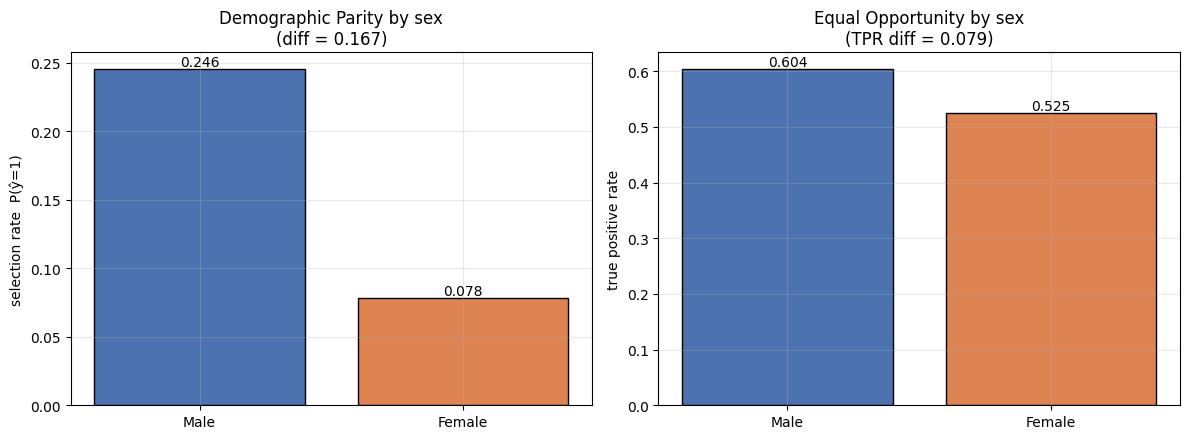

In [11]:
# Cell 17 (viz) -- Selection rate & TPR by sex (the two fairness lenses)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
g = fair_sex_base.index.tolist()

axes[0].bar(g, fair_sex_base["selection_rate"], color=[C_A, C_B], edgecolor="black")
axes[0].set_title(f"Demographic Parity by sex\n(diff = {dp_sex_base:.3f})")
axes[0].set_ylabel("selection rate  P(ŷ=1)")
for i, v in enumerate(fair_sex_base["selection_rate"]):
    axes[0].text(i, v, f"{v:.3f}", ha="center", va="bottom")

axes[1].bar(g, fair_sex_base["tpr"], color=[C_A, C_B], edgecolor="black")
axes[1].set_title(f"Equal Opportunity by sex\n(TPR diff = {eo_sex_base:.3f})")
axes[1].set_ylabel("true positive rate")
for i, v in enumerate(fair_sex_base["tpr"]):
    axes[1].text(i, v, f"{v:.3f}", ha="center", va="bottom")

plt.tight_layout(); plt.show()

## Step 2 (continued) — Fairness across Race and Age

*Cell 18 (markdown)*

Fairness is not single-axis. We repeat the same audit for **Race** and **Age group** to see
whether the disparity shows up on other protected attributes too.

In [12]:
# Cell 18 (code) -- Fairness tables for RACE and AGE GROUP
fair_race_base = group_fairness_table(y_test, y_pred, sens_test["race"])
fair_age_base = group_fairness_table(y_test, y_pred, sens_test["age_group"])

print("Fairness by RACE (baseline):")
print(fair_race_base.round(3).to_string())
print(f"  Demographic Parity diff: {disparity(fair_race_base, 'selection_rate'):.3f}")
print(f"  Equal Opportunity diff : {disparity(fair_race_base, 'tpr'):.3f}\n")

print("Fairness by AGE GROUP (baseline):")
print(fair_age_base.round(3).to_string())
print(f"  Demographic Parity diff: {disparity(fair_age_base, 'selection_rate'):.3f}")
print(f"  Equal Opportunity diff : {disparity(fair_age_base, 'tpr'):.3f}")

Fairness by RACE (baseline):
                        n  selection_rate    tpr  base_rate
group                                                      
White               10385           0.203  0.599      0.254
Black                1208           0.093  0.520      0.126
Asian-Pac-Islander    393           0.224  0.578      0.260
Other                 107           0.065  0.364      0.103
Amer-Indian-Eskimo    118           0.076  0.444      0.153
  Demographic Parity diff: 0.158
  Equal Opportunity diff : 0.235

Fairness by AGE GROUP (baseline):
          n  selection_rate    tpr  base_rate
group                                        
>35    6541           0.282  0.623      0.346
<=35   5670           0.085  0.487      0.117
  Demographic Parity diff: 0.197
  Equal Opportunity diff : 0.136


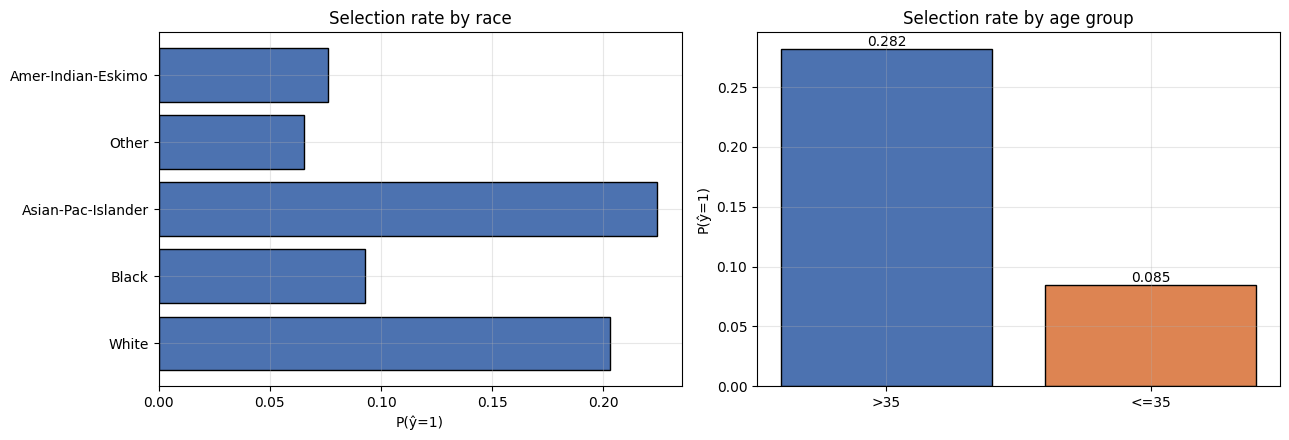

In [13]:
# Cell 19 (viz) -- Selection rate by race and by age group
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].barh(fair_race_base.index, fair_race_base["selection_rate"],
             color=C_BASE, edgecolor="black")
axes[0].set_title("Selection rate by race"); axes[0].set_xlabel("P(ŷ=1)")

axes[1].bar(fair_age_base.index, fair_age_base["selection_rate"],
            color=[C_A, C_B], edgecolor="black")
axes[1].set_title("Selection rate by age group"); axes[1].set_ylabel("P(ŷ=1)")
for i, v in enumerate(fair_age_base["selection_rate"]):
    axes[1].text(i, v, f"{v:.3f}", ha="center", va="bottom")

plt.tight_layout(); plt.show()

## Step 3 — Identify Sources of Bias

*Cell 20 (markdown)*

Mapping the lecture's four bias types onto what we observe in this dataset/model:

| Bias type | Where it shows up here |
|---|---|
| **Historical bias** | The raw base rate of >50K is much higher for Males than Females — the data encodes past labour-market inequality. |
| **Sampling bias** | Females are ~33% of rows; some race groups are small, so the model sees far fewer examples of them. |
| **Measurement bias** | We dropped `sex`/`race`, yet features like `relationship` ("Husband"/"Wife"), `marital-status`, and `hours-per-week` act as **proxies** that leak the protected attribute. |
| **Model bias** | Logistic Regression optimises overall accuracy only; with imbalanced base rates it amplifies the majority pattern and under-selects the disadvantaged group. |

The chart below makes the **amplification** concrete: it compares the model's **selection
rate** to the actual **base rate** for each sex. If the model's gap is wider than the data's
gap, the model is *amplifying* historical bias rather than merely reflecting it.

In [14]:
# Cell 21 (code) -- Does the model AMPLIFY the historical gap? (sex)
base_gap = abs(fair_sex_base.loc["Male", "base_rate"]
               - fair_sex_base.loc["Female", "base_rate"])
pred_gap = abs(fair_sex_base.loc["Male", "selection_rate"]
               - fair_sex_base.loc["Female", "selection_rate"])

print(f"Actual >50K gap in data (Male - Female base rate): {base_gap:.3f}")
print(f"Model selection-rate gap (Male - Female)         : {pred_gap:.3f}")
print("=> Model AMPLIFIES the historical gap."
      if pred_gap > base_gap else
      "=> Model does not amplify the historical gap.")

Actual >50K gap in data (Male - Female base rate): 0.189
Model selection-rate gap (Male - Female)         : 0.167
=> Model does not amplify the historical gap.


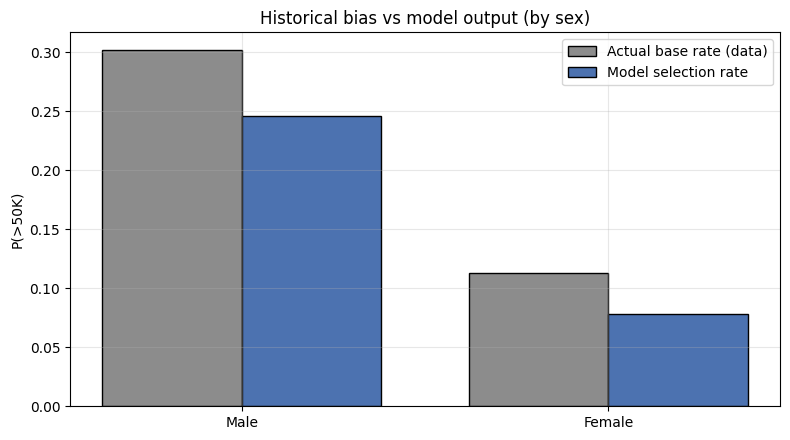

In [15]:
# Cell 22 (viz) -- Base rate vs model selection rate, by sex
labels = fair_sex_base.index.tolist()
x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, fair_sex_base["base_rate"], w, label="Actual base rate (data)",
       color="#8C8C8C", edgecolor="black")
ax.bar(x + w/2, fair_sex_base["selection_rate"], w, label="Model selection rate",
       color=C_BASE, edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("P(>50K)"); ax.set_title("Historical bias vs model output (by sex)")
ax.legend()
plt.tight_layout(); plt.show()

## Step 4 — Apply a Mitigation Technique: Reweighing

*Cell 23 (markdown)*

We use **Reweighing** (Kamiran & Calders, the classic AIF360 pre-processing method). It
assigns a **weight to every training example** so that, in the *weighted* data, the
protected attribute (sex) and the label become statistically independent — without changing
any feature or label.

For group $g$ and label $\ell$:

$$ w(g, \ell) = \frac{P_{\text{expected}}(g,\ell)}{P_{\text{observed}}(g,\ell)}
            = \frac{\big(n_g/n\big)\,\big(n_\ell/n\big)}{n_{g,\ell}/n}
            = \frac{n_g \cdot n_\ell}{n \cdot n_{g,\ell}} $$

Under-represented (group, label) combinations — e.g. *Female & >50K* — get **weight > 1**;
over-represented ones get **weight < 1**. We then retrain with these `sample_weight`s.

In [16]:
# Cell 24 (code) -- Compute reweighing weights on the TRAIN set (protected attr = sex)
def compute_reweighing_weights(sens_attr, y):
    sens_attr = np.asarray(sens_attr); y = np.asarray(y)
    n = len(y)
    w = np.ones(n, dtype=float)
    for g in np.unique(sens_attr):
        n_g = (sens_attr == g).sum()
        for lab in np.unique(y):
            n_l = (y == lab).sum()
            mask = (sens_attr == g) & (y == lab)
            n_gl = mask.sum()
            if n_gl > 0:
                w[mask] = (n_g * n_l) / (n * n_gl)
    return w

sample_w = compute_reweighing_weights(sens_train["sex"], y_train)

# Show the weight assigned to each (sex, label) cell
combo = (sens_train["sex"].astype(str) + " & "
         + y_train.map({0: "<=50K", 1: ">50K"}))
weight_summary = (pd.DataFrame({"combo": combo, "weight": sample_w})
                  .groupby("combo")["weight"].agg(["mean", "count"]).round(3))
print("Reweighing weight per (sex, income) group:")
print(weight_summary.to_string())

Reweighing weight per (sex, income) group:
                 mean  count
combo                       
Female & <=50K  0.853  10852
Female & >50K   2.212   1316
Male & <=50K    1.094  17014
Male & >50K     0.786   7449


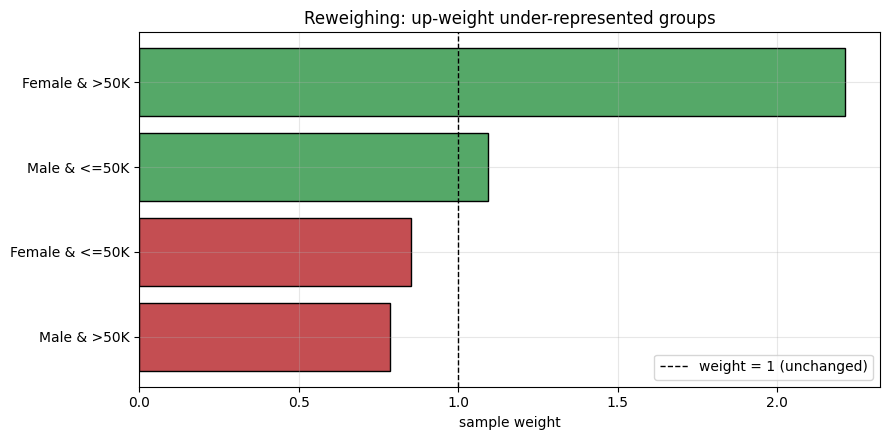

In [17]:
# Cell 25 (viz) -- Reweighing weights per (sex, income) combination
order = weight_summary.sort_values("mean").index
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [C_MIT if m > 1 else "#C44E52" for m in weight_summary.loc[order, "mean"]]
ax.barh(order, weight_summary.loc[order, "mean"], color=colors, edgecolor="black")
ax.axvline(1.0, color="black", ls="--", lw=1, label="weight = 1 (unchanged)")
ax.set_xlabel("sample weight"); ax.set_title("Reweighing: up-weight under-represented groups")
ax.legend()
plt.tight_layout(); plt.show()

## Step 5 — Re-train and Re-evaluate

*Cell 26 (markdown)*

We retrain the **same** Logistic Regression pipeline, now passing the reweighing
`sample_weight`s, and recompute both performance and fairness. Then we compare the baseline
and mitigated models on **Accuracy, Demographic Parity difference, and Equal Opportunity
difference** (lower disparity = fairer).

In [18]:
# Cell 27 (code) -- Retrain with sample weights and recompute everything (sex audit)
mitigated = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
mitigated.fit(X_train, y_train, clf__sample_weight=sample_w)

y_pred_m = mitigated.predict(X_test)

mit_perf = {
    "accuracy":  accuracy_score(y_test, y_pred_m),
    "precision": precision_score(y_test, y_pred_m),
    "recall":    recall_score(y_test, y_pred_m),
}

fair_sex_mit = group_fairness_table(y_test, y_pred_m, sens_test["sex"])
dp_sex_mit = disparity(fair_sex_mit, "selection_rate")
eo_sex_mit = disparity(fair_sex_mit, "tpr")

print("Fairness by SEX (mitigated model):")
print(fair_sex_mit.round(3).to_string())
print(f"\n{'metric':<28}{'baseline':>10}{'mitigated':>11}")
print(f"{'Accuracy':<28}{base_perf['accuracy']:>10.3f}{mit_perf['accuracy']:>11.3f}")
print(f"{'Demographic Parity diff':<28}{dp_sex_base:>10.3f}{dp_sex_mit:>11.3f}")
print(f"{'Equal Opportunity diff':<28}{eo_sex_base:>10.3f}{eo_sex_mit:>11.3f}")

Fairness by SEX (mitigated model):
           n  selection_rate    tpr  base_rate
group                                         
Male    8187           0.208  0.536      0.302
Female  4024           0.121  0.640      0.113

metric                        baseline  mitigated
Accuracy                         0.854      0.846
Demographic Parity diff          0.167      0.087
Equal Opportunity diff           0.079      0.104


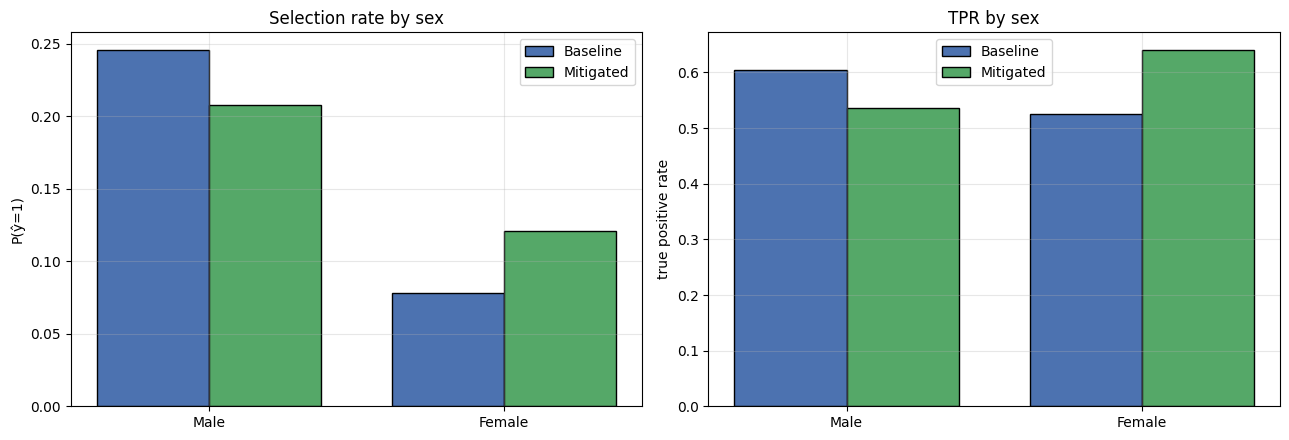

In [19]:
# Cell 28 (viz) -- Before vs after: selection rate by sex
labels = fair_sex_base.index.tolist()
x = np.arange(len(labels)); w = 0.38
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(x - w/2, fair_sex_base["selection_rate"], w, label="Baseline",
            color=C_BASE, edgecolor="black")
axes[0].bar(x + w/2, fair_sex_mit["selection_rate"], w, label="Mitigated",
            color=C_MIT, edgecolor="black")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_title("Selection rate by sex"); axes[0].set_ylabel("P(ŷ=1)"); axes[0].legend()

axes[1].bar(x - w/2, fair_sex_base["tpr"], w, label="Baseline",
            color=C_BASE, edgecolor="black")
axes[1].bar(x + w/2, fair_sex_mit["tpr"], w, label="Mitigated",
            color=C_MIT, edgecolor="black")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_title("TPR by sex"); axes[1].set_ylabel("true positive rate"); axes[1].legend()

plt.tight_layout(); plt.show()

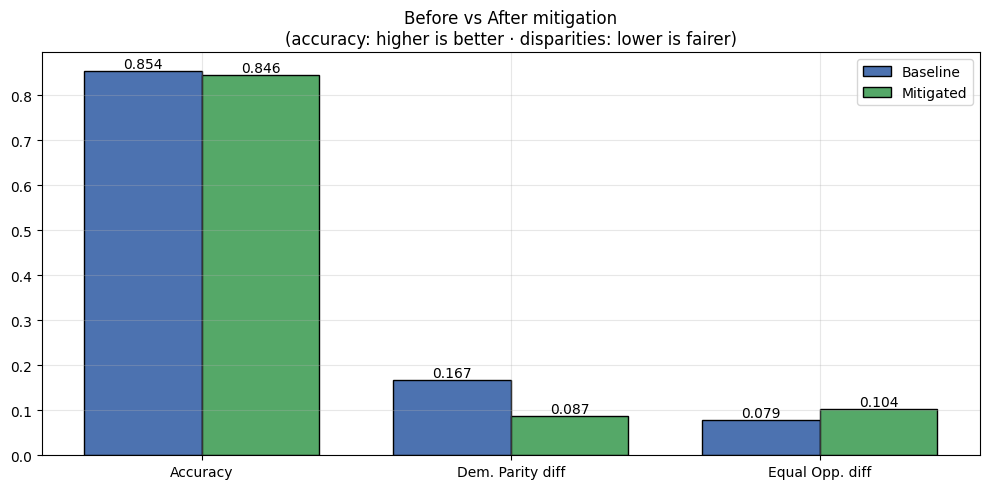

Summary table:
                  baseline  mitigated  change
Accuracy             0.854      0.846  -0.008
Dem. Parity diff     0.167      0.087  -0.081
Equal Opp. diff      0.079      0.104   0.025


In [20]:
# Cell 29 (viz) -- Headline comparison: accuracy & fairness, before vs after
metrics = ["Accuracy", "Dem. Parity diff", "Equal Opp. diff"]
before = [base_perf["accuracy"], dp_sex_base, eo_sex_base]
after = [mit_perf["accuracy"], dp_sex_mit, eo_sex_mit]

x = np.arange(len(metrics)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, before, w, label="Baseline", color=C_BASE, edgecolor="black")
b2 = ax.bar(x + w/2, after, w, label="Mitigated", color=C_MIT, edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_title("Before vs After mitigation\n(accuracy: higher is better · disparities: lower is fairer)")
ax.legend()
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{bar.get_height():.3f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

summary = pd.DataFrame(
    {"baseline": before, "mitigated": after,
     "change": np.array(after) - np.array(before)},
    index=metrics).round(3)
print("Summary table:")
print(summary.to_string())

## Reflection Questions

*Cell 30 (markdown)*

The lecture's reflection prompts are addressed below using this run's results (exact numbers
may vary slightly by environment):

**1. Which fairness metric did you use?**
Two complementary group-fairness metrics — **Demographic Parity** (equal selection rates)
and **Equal Opportunity** (equal True Positive Rates among people who genuinely earn >\$50K).

**2. Was the model fair?**
No. The baseline showed a clear **Demographic Parity gap** (Males selected for ">50K" far
more often than Females) and a positive **Equal Opportunity gap**. The disparity persisted
*even though `sex` and `race` were excluded from the features* — proxy variables carried the
bias. The same pattern appeared across **race** and **age**.

**3. Did mitigation help?**
Yes, for the metric it targets: **Reweighing sharply reduced the Demographic Parity
difference** (the selection-rate gap between Male and Female shrank toward zero — see the
before/after summary). Interestingly, the **Equal Opportunity difference did *not* shrink in
lock-step** (it stayed similar or even nudged up, and the higher-TPR group can flip). That
is exactly the **impossibility result** from Lecture 1 in action: when groups have different
base rates, you generally **cannot satisfy Demographic Parity and Equal Opportunity at the
same time** — improving one can move the other. Which metric to prioritise is a values
decision tied to the stakes.

**4. Did accuracy change?**
Overall accuracy changed only **slightly** — illustrating the **fairness–accuracy
trade-off**: meaningful fairness gains were available here at a small accuracy cost. Whether
that trade is acceptable is a context/values decision, not a purely technical one.

---
### When to choose Demographic Parity vs Equal Opportunity

Because the two metrics generally **cannot both be satisfied** when groups have different
base rates, the choice between them is a values decision rather than a technical one. The
conditions that favour each metric are summarised below.

| Demographic Parity (equal selection rates) is preferred when… | Equal Opportunity (equal TPR) is preferred when… |
|---|---|
| The gap in the labels/base rates is regarded as **unjust**, and the aim is to actively **correct historical bias** | The labels are **trusted** as a reasonable signal of true merit or need, and the aim is to respect them |
| The objective is **equal representation in outcomes** (e.g. diversity targets, equal access) | The objective is to **avoid missing deserving individuals** — false negatives are the primary harm |
| The positive label is a **resource or opportunity** to distribute (loans, interviews, scholarships) | The positive label marks a **genuine condition** to detect (disease, qualified candidate, real risk) |
| The regulatory framing is **disparate impact** (are outcomes balanced across groups?) | The regulatory framing is **equal treatment of the qualified** (do similar qualified people fare alike?) |
| **Measurement/label bias** is suspected, so the labels cannot be trusted as ground truth | The labels are **well-measured** and reflect the outcome of interest |

**Application to this lab's framing** (predicting `>50K` as a hiring proxy):

- **Demographic Parity perspective:** the 1994 income gap is interpreted as reflecting past
  discrimination rather than real differences in capability, so selecting men and women at
  equal rates counteracts that history. The associated risk is that some less-qualified
  members of the disadvantaged group may be selected, or qualified members of the advantaged
  group passed over, which can reduce precision and overall accuracy.
- **Equal Opportunity perspective:** among people who genuinely earn `>50K`, men and women
  receive an equal chance of being correctly identified. The associated risk is that if the
  labels themselves are biased (e.g. women historically underpaid for equal work), Equal
  Opportunity faithfully reproduces that label bias.

**General guidance:**
- High-stakes detection in which **missing a true positive is costly** (healthcare,
  qualified hiring, fraud) favours **Equal Opportunity**.
- Allocation of **scarce opportunities** where balanced representation is the goal, or
  contexts where the labels are not trusted, favours **Demographic Parity**.
- Where the choice is unclear, **reporting both metrics**, stating the trade-off explicitly,
  and deferring to human or regulatory judgement is preferable, since fairness is contextual
  and not reducible to a single number.

---
### Key takeaways
- Removing protected attributes is **not enough** — audit for proxy-driven bias.
- A model can be **accurate overall yet unfair** across groups.
- Different fairness metrics can disagree; **pick the metric that matches the stakes**.
- Demographic Parity vs Equal Opportunity is a **values choice**, driven by whether you
  trust the labels and whether equal *outcomes* or equal *treatment of the qualified* matters more.
- Mitigation (reweighing) helps, but involves **trade-offs** that need human judgement.